# 06 — SHAP Analysis

**Goal:** Explain model predictions using SHAP values for all 7 models on the `poverty_3` threshold.  
**Reads:** `data/processed/train.csv`, `data/processed/test.csv`, `data/processed/ssp_forecast_panel.csv`, model `.pkl` files  
**Outputs:** All plots saved to `outputs/shap/`

Sections:
1. SHAP summary & importance plots for all 7 models
2. Deep-dive on the best model (waterfall, dependence plots)
3. Scenario comparison (SSP1 vs SSP4 vs SSP5 for one country)
4. Cross-model feature importance comparison
5. GAM partial dependence plots

## Imports and paths

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

DATA_PROCESSED = Path("../data/processed")
MODELS_DIR = Path("../models")
OUTPUTS_DIR = Path("../outputs")
SHAP_DIR = OUTPUTS_DIR / "shap"
SHAP_DIR.mkdir(parents=True, exist_ok=True)

FEATURES = ["gdp_per_capita", "hdi", "control_of_corruption", "employment_agriculture", "gini"]
TARGET = "poverty_3"
MODEL_NAMES = ["XGBoost_CPU", "XGBoost_GPU", "LightGBM", "RandomForest", "Ridge", "MLP", "GAM"]
TREE_MODELS = {"XGBoost_CPU", "XGBoost_GPU", "LightGBM", "RandomForest"}
NEEDS_SCALING = {"Ridge", "MLP"}

plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (10, 6)

## Load data and models

In [2]:
train_full = pd.read_csv(DATA_PROCESSED / "train.csv")
test_full = pd.read_csv(DATA_PROCESSED / "test.csv")

# Filter to rows with valid target
train_df = train_full.dropna(subset=[TARGET])
test_df = test_full.dropna(subset=[TARGET])

X_train = train_df[FEATURES]
X_test = test_df[FEATURES]
y_test = test_df[TARGET].values

# Load scaler
scaler = joblib.load(MODELS_DIR / f"scaler_{TARGET}.pkl")
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=FEATURES, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=FEATURES, index=X_test.index)

# Background sample for KernelExplainer (50 rows from training data)
np.random.seed(42)
bg_idx = np.random.choice(len(X_train), size=50, replace=False)
X_bg = X_train.iloc[bg_idx]
X_bg_scaled = X_train_scaled.iloc[bg_idx]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Background sample for KernelExplainer: {X_bg.shape}")

Train: (1626, 5), Test: (373, 5)
Background sample for KernelExplainer: (50, 5)


In [3]:
# Load all models
models = {}
for name in MODEL_NAMES:
    path = MODELS_DIR / f"{name}_{TARGET}.pkl"
    if path.exists():
        models[name] = joblib.load(path)
        print(f"  Loaded {name}")
    else:
        print(f"  MISSING: {path.name}")

  Loaded XGBoost_CPU
  Loaded XGBoost_GPU
  Loaded LightGBM
  Loaded RandomForest
  Loaded Ridge
  Loaded MLP
  Loaded GAM


### Identify the best model

In [4]:
# Load comparison results to find the best model
comparison = pd.read_csv(OUTPUTS_DIR / "model_comparison.csv")
best_row = comparison[comparison["Threshold"] == TARGET].sort_values("R2", ascending=False).iloc[0]
BEST_MODEL_NAME = best_row["Model"]
print(f"Best model for {TARGET}: {BEST_MODEL_NAME} (R² = {best_row['R2']:.4f})")

Best model for poverty_3: XGBoost_CPU (R² = 0.7167)


## 1. SHAP summary & importance plots for all models

Explainer choice:
- Tree models → `shap.TreeExplainer` (exact)
- Ridge → `shap.LinearExplainer` (exact for linear models)
- MLP, GAM → `shap.KernelExplainer` (with 50-row background sample)

> **Note:** KernelExplainer results are approximate (50-row background) and may be noisier than TreeExplainer, which computes exact SHAP values for tree-based models.

In [5]:
def get_shap_values(model_name, model):
    """
    Compute SHAP values for a model on the test set.
    Returns (shap_values, X_for_plot) where X_for_plot has feature names.
    """
    if model_name in TREE_MODELS:
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X_test)
        return sv, X_test
    
    elif model_name == "Ridge":
        explainer = shap.LinearExplainer(model, X_train_scaled)
        sv = explainer.shap_values(X_test_scaled)
        # Use unscaled X for display so feature values are interpretable
        return sv, X_test
    
    elif model_name == "MLP":
        explainer = shap.KernelExplainer(model.predict, X_bg_scaled.values)
        sv = explainer.shap_values(X_test_scaled.values)
        return sv, X_test
    
    elif model_name == "GAM":
        explainer = shap.KernelExplainer(model.predict, X_bg.values)
        sv = explainer.shap_values(X_test.values)
        return sv, X_test
    
    else:
        raise ValueError(f"Unknown model: {model_name}")

In [6]:
# Compute and store SHAP values for all models
all_shap = {}

for model_name, model in models.items():
    print(f"Computing SHAP for {model_name}...", end=" ")
    try:
        sv, X_plot = get_shap_values(model_name, model)
        all_shap[model_name] = (sv, X_plot)
        print(f"done — shape: {sv.shape}")
    except Exception as e:
        print(f"FAILED: {e}")

print(f"\nSHAP computed for {len(all_shap)} models")

Computing SHAP for XGBoost_CPU... done — shape: (373, 5)
Computing SHAP for XGBoost_GPU... done — shape: (373, 5)
Computing SHAP for LightGBM... done — shape: (373, 5)
Computing SHAP for RandomForest... done — shape: (373, 5)
Computing SHAP for Ridge... done — shape: (373, 5)
Computing SHAP for MLP... 

  0%|          | 0/373 [00:00<?, ?it/s]

done — shape: (373, 5)
Computing SHAP for GAM... 

  0%|          | 0/373 [00:00<?, ?it/s]

done — shape: (373, 5)

SHAP computed for 7 models


### Generate summary plots (beeswarm) and importance plots (bar) for each model

--- XGBoost_CPU ---


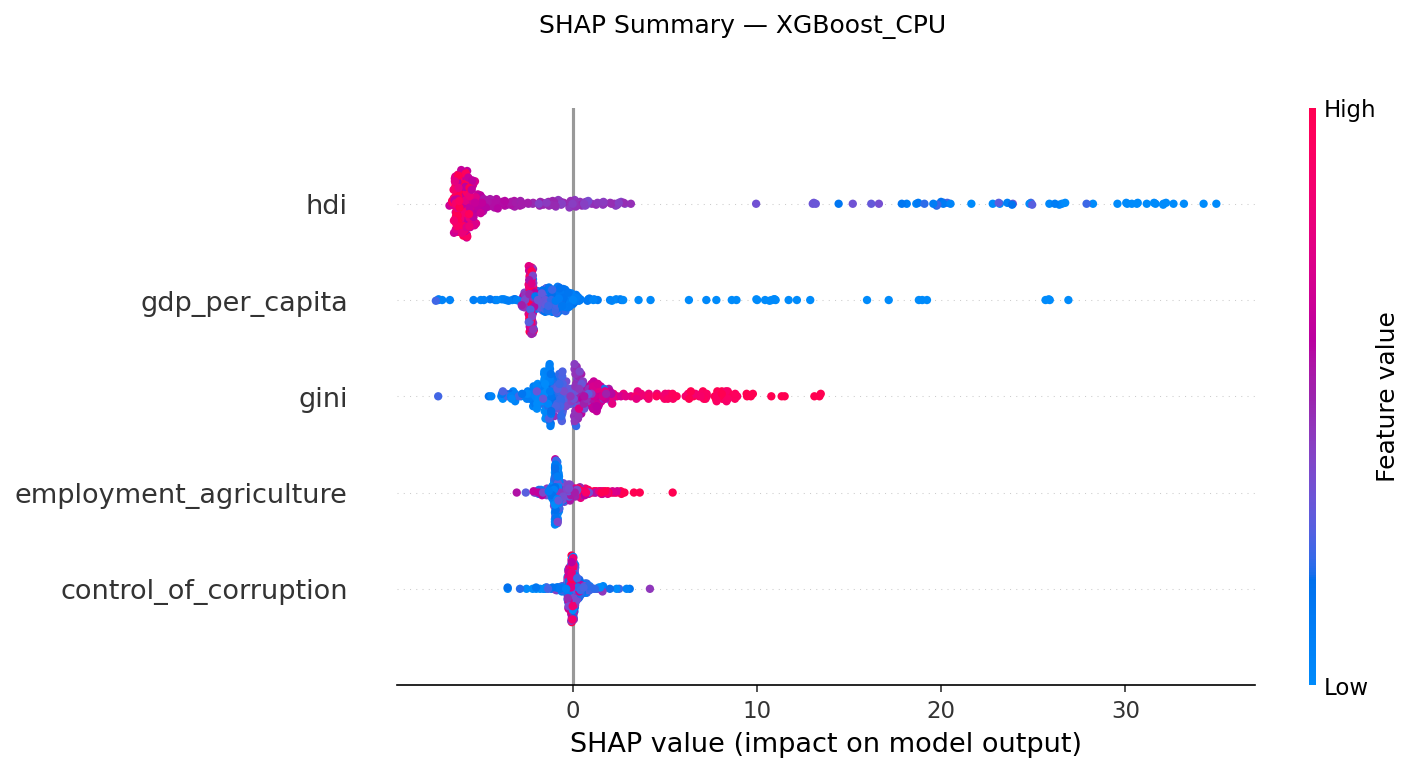

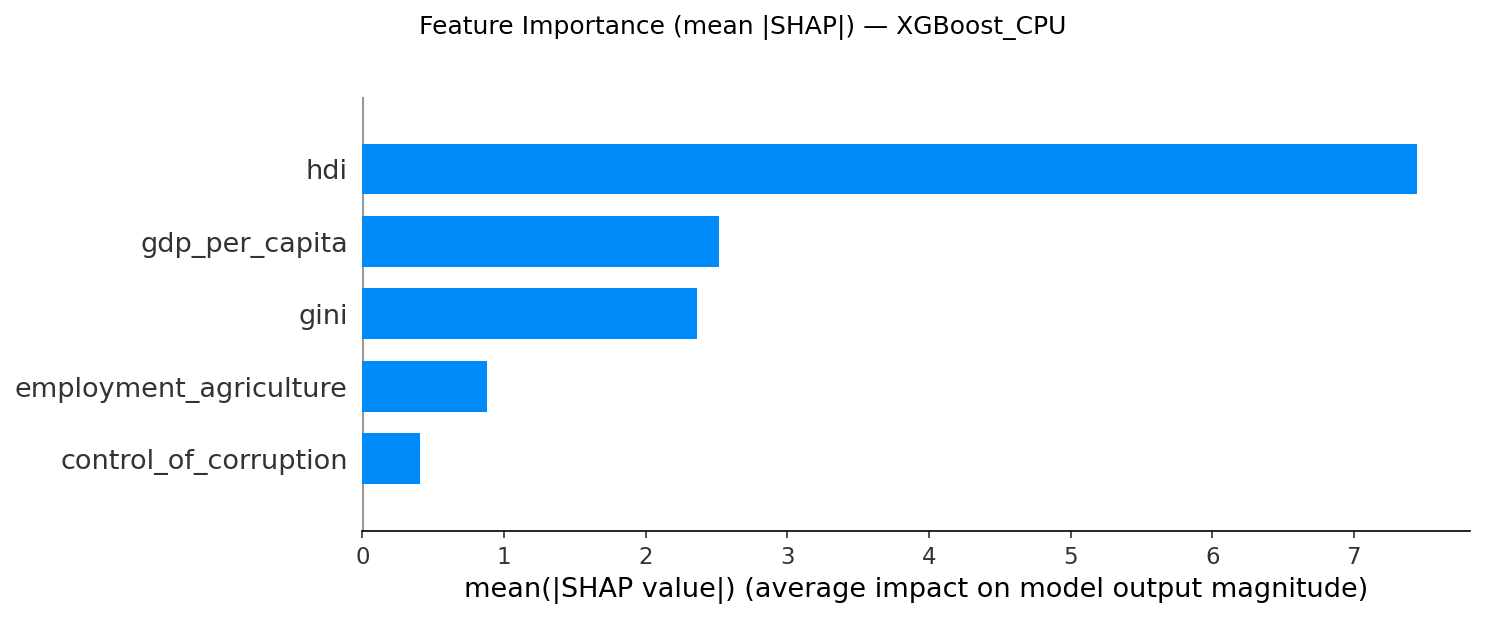


--- XGBoost_GPU ---


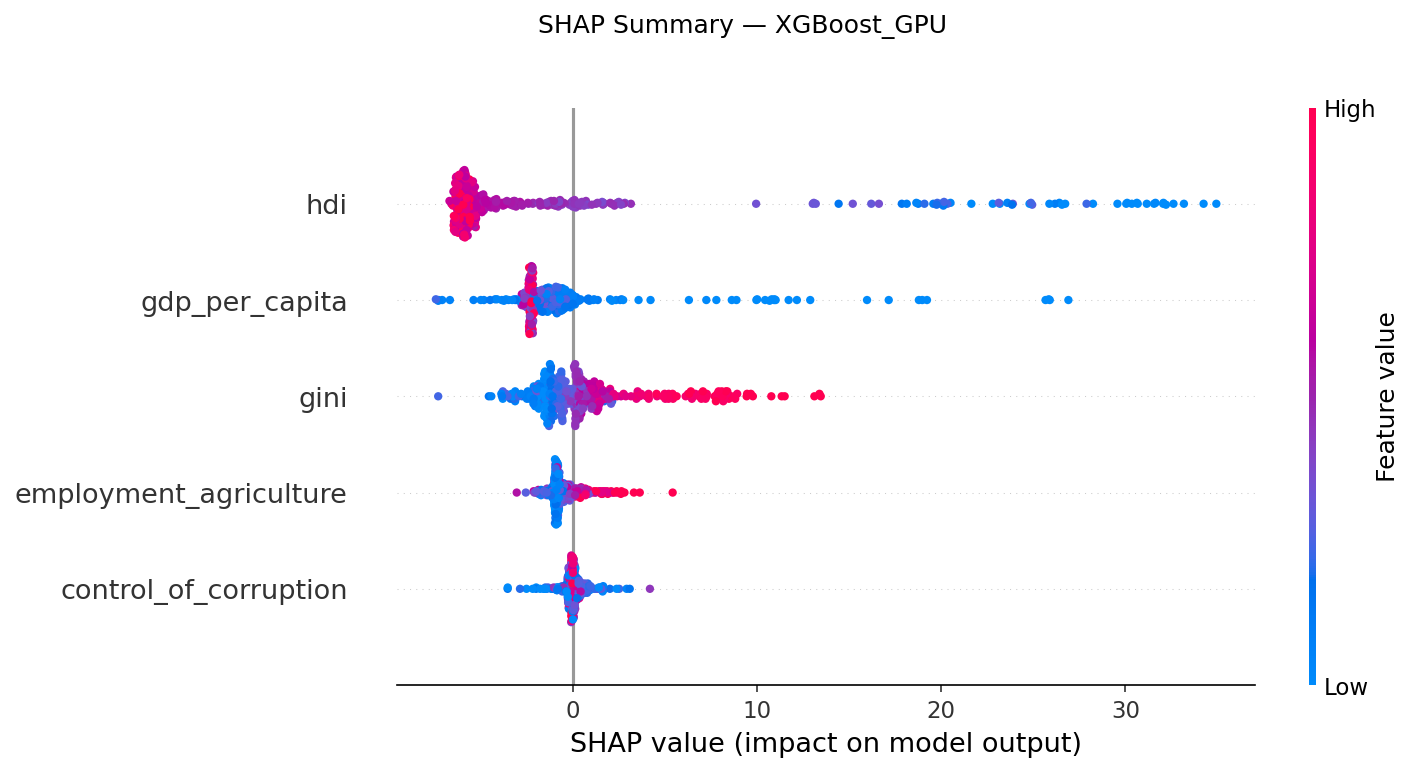

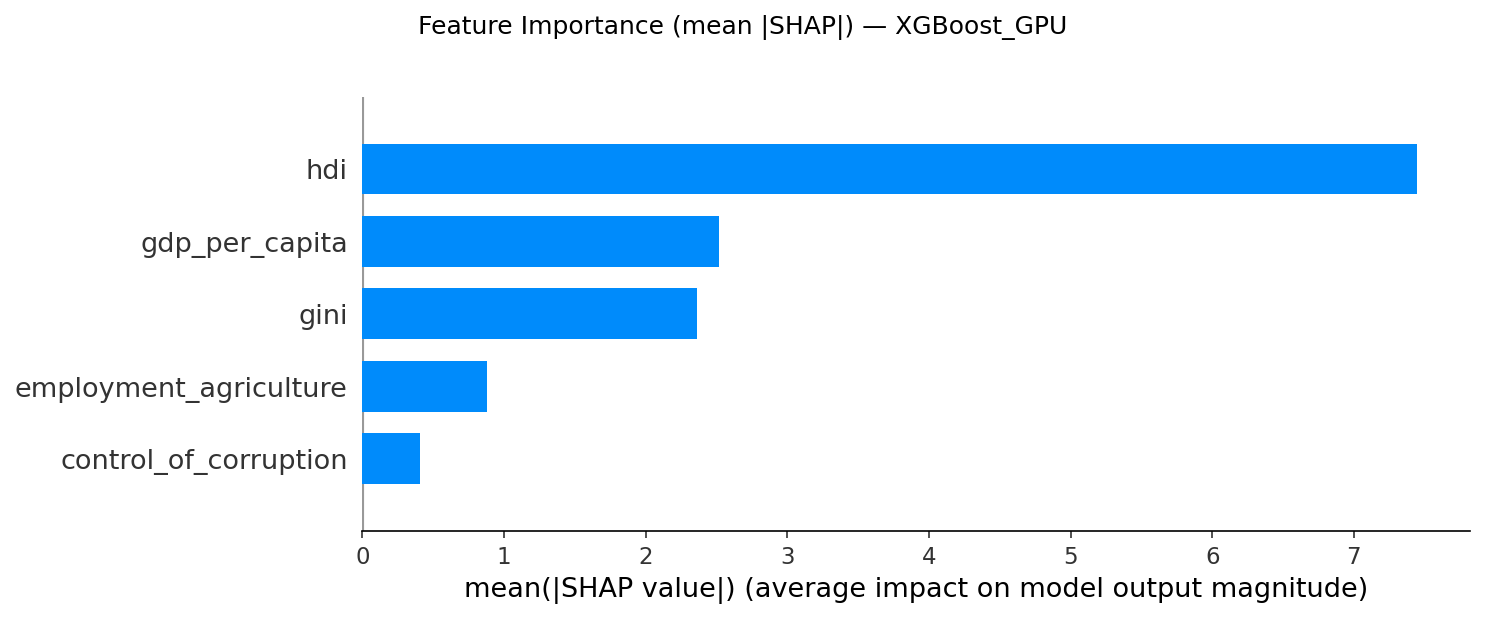


--- LightGBM ---


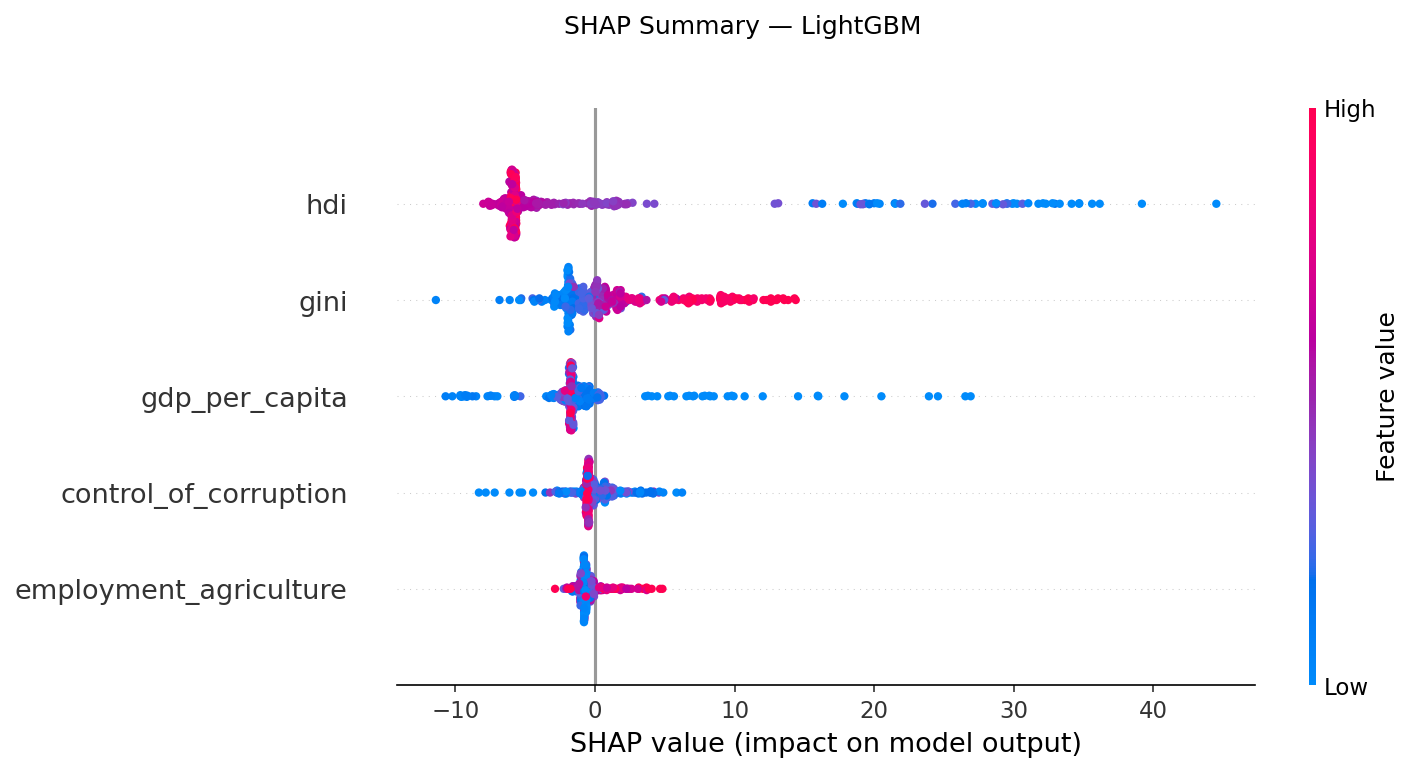

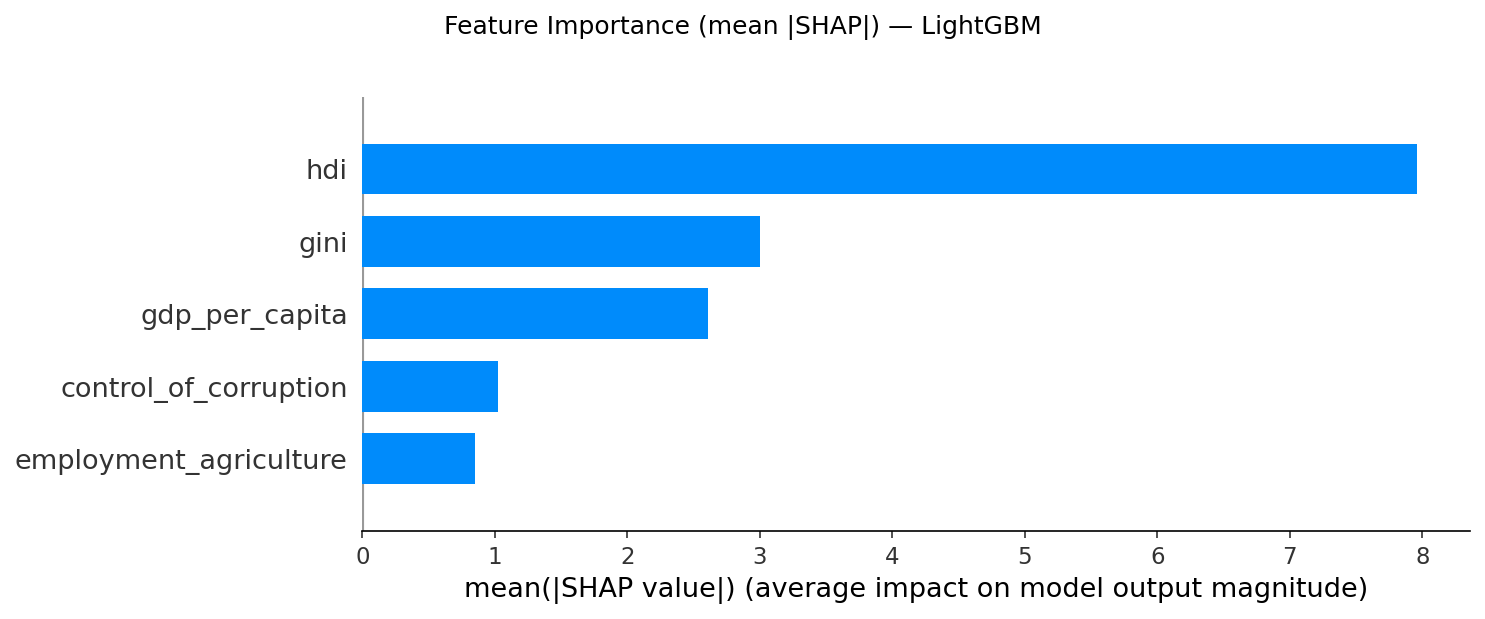


--- RandomForest ---


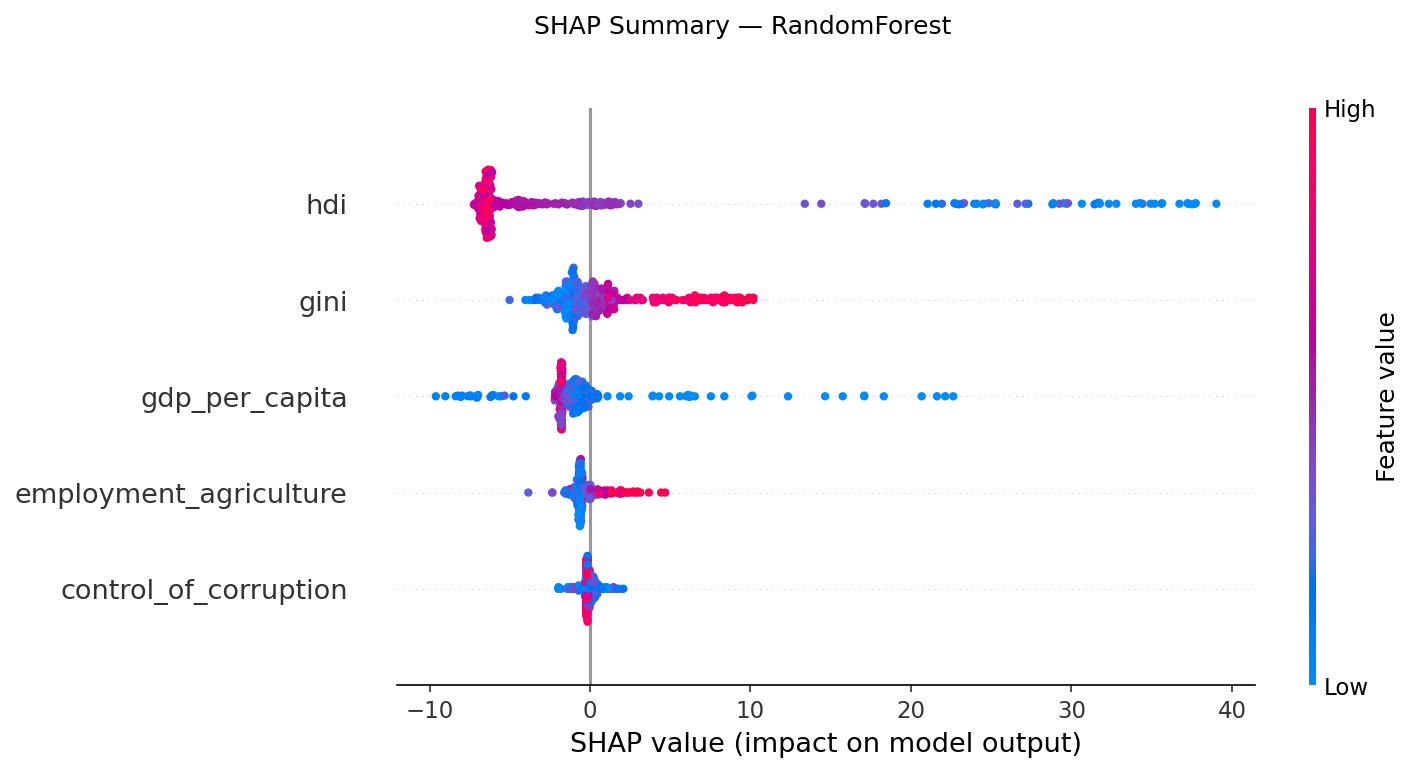

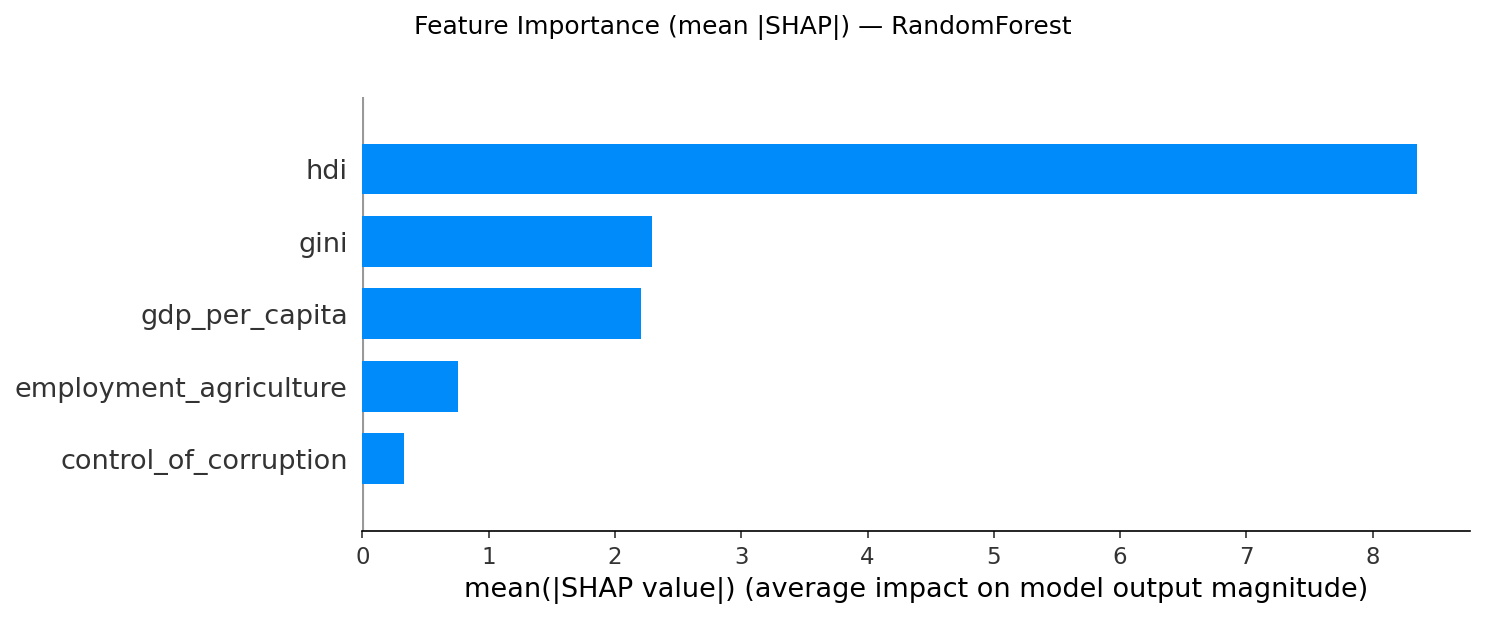


--- Ridge ---


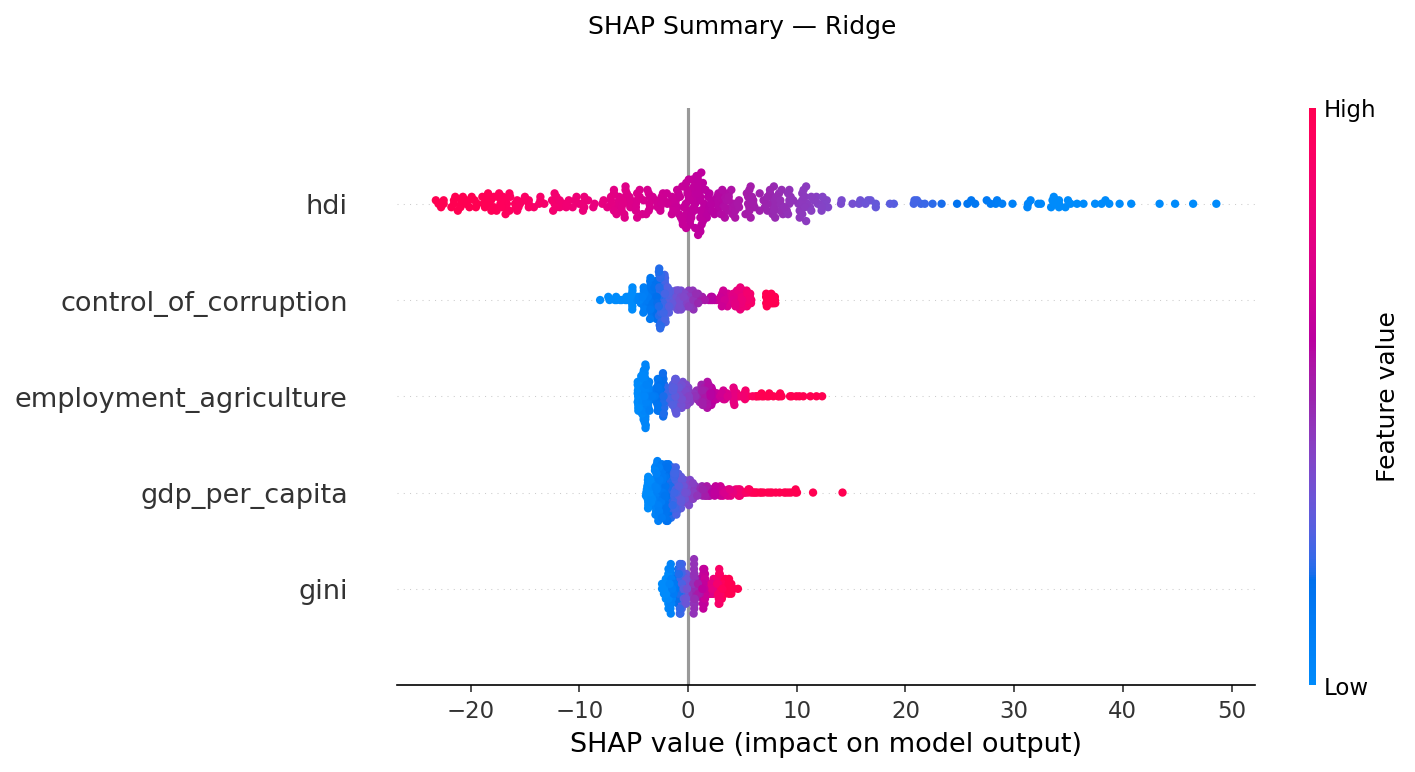

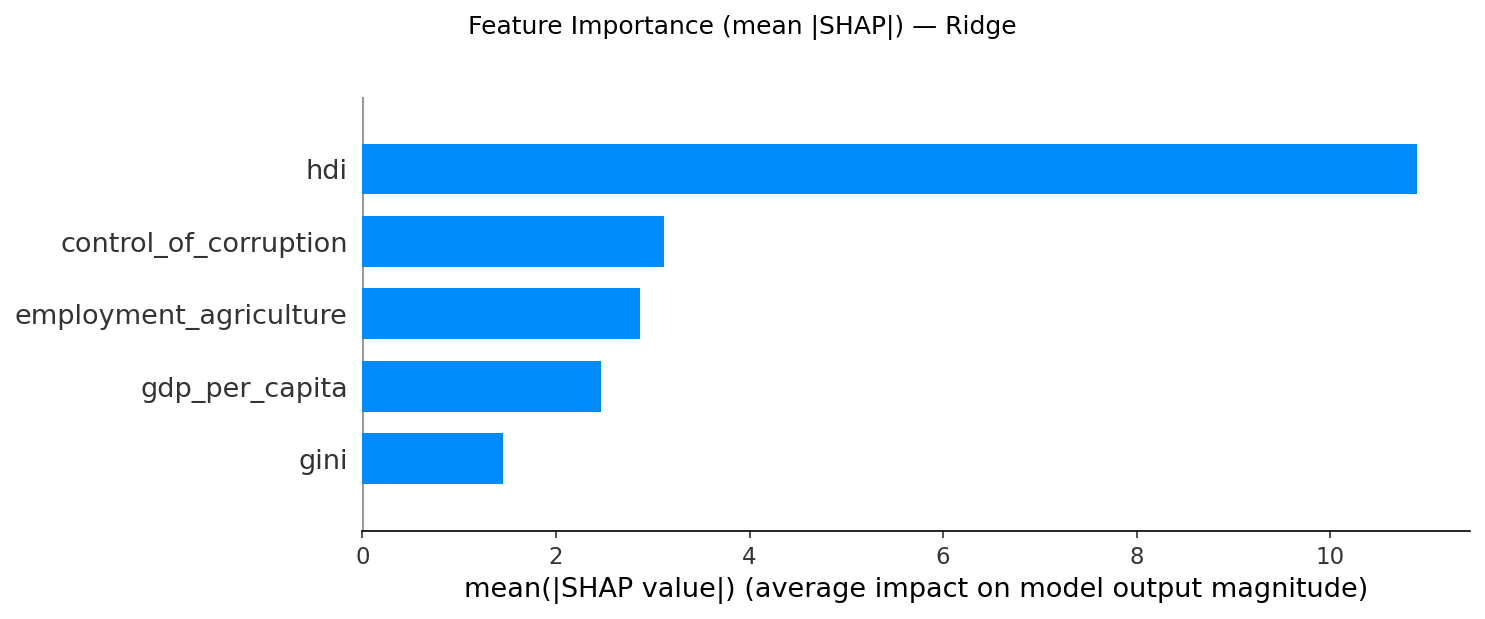


--- MLP ---


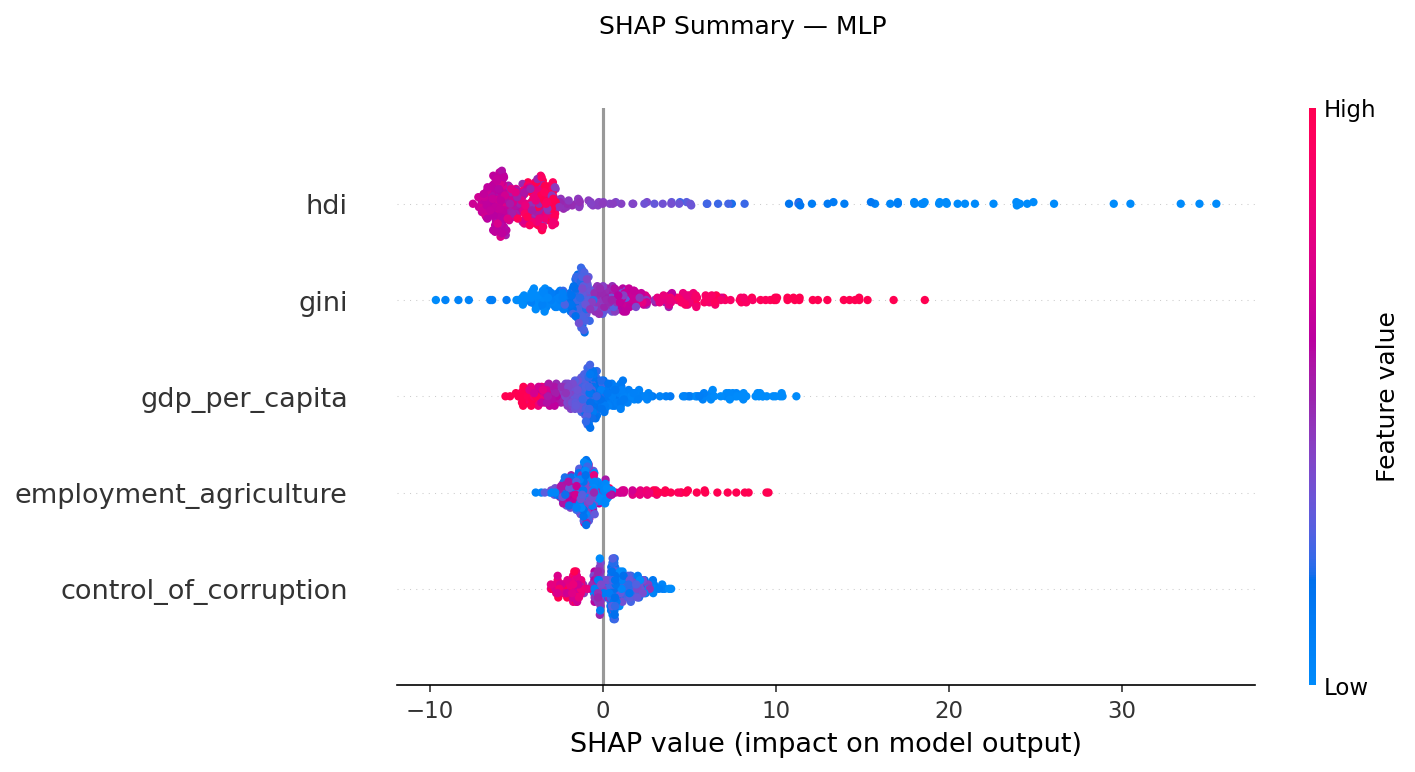

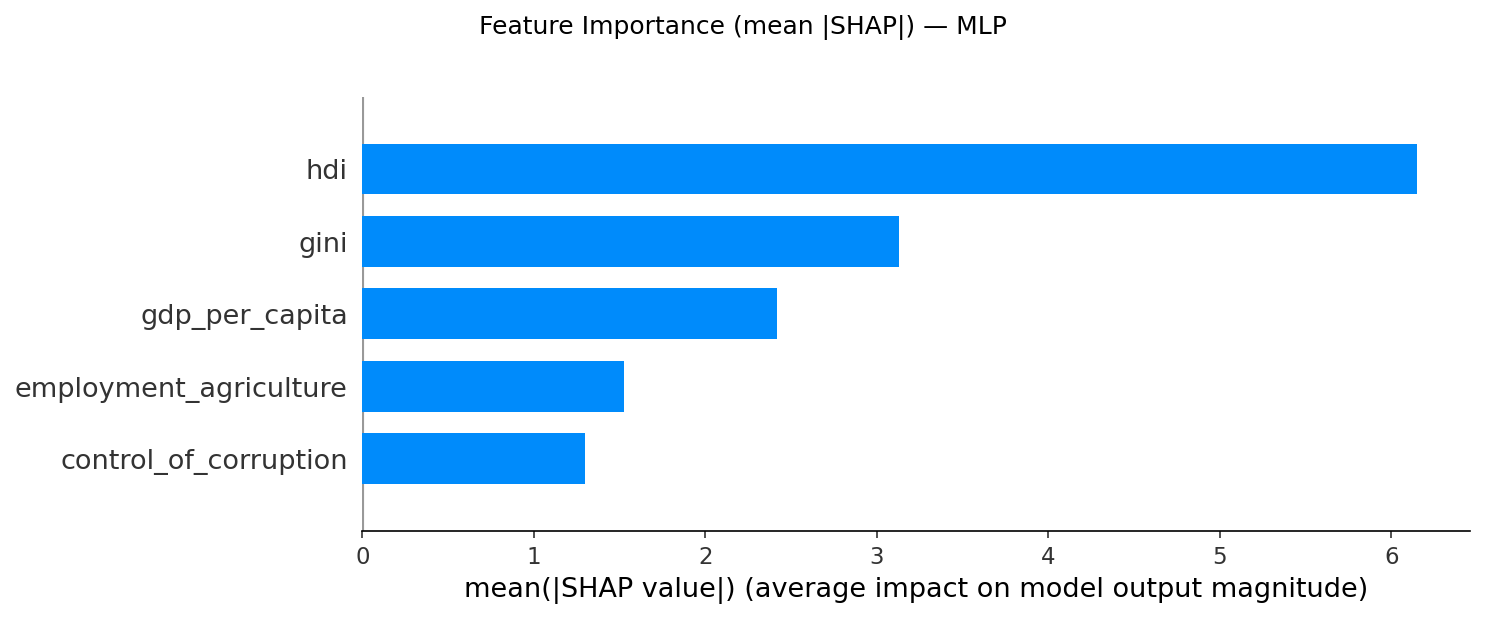


--- GAM ---


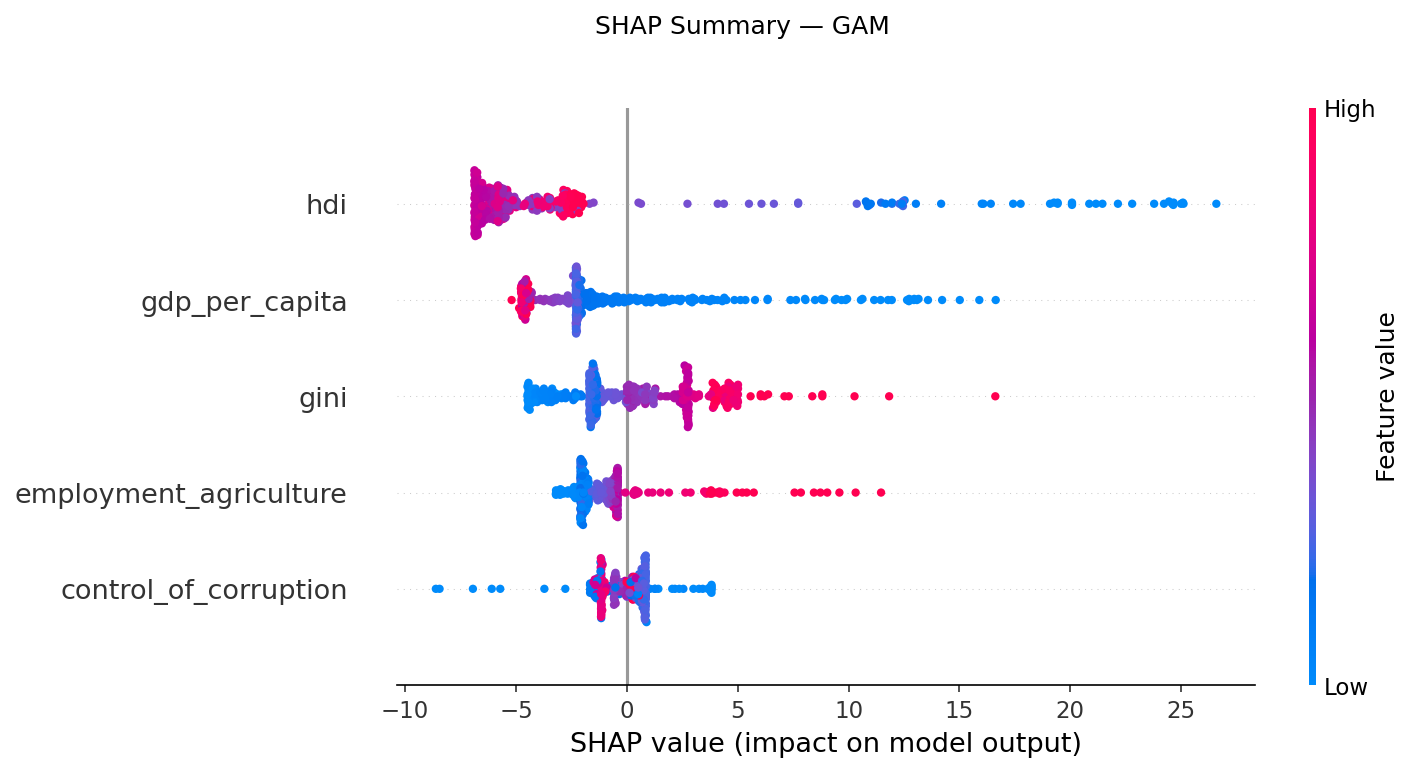

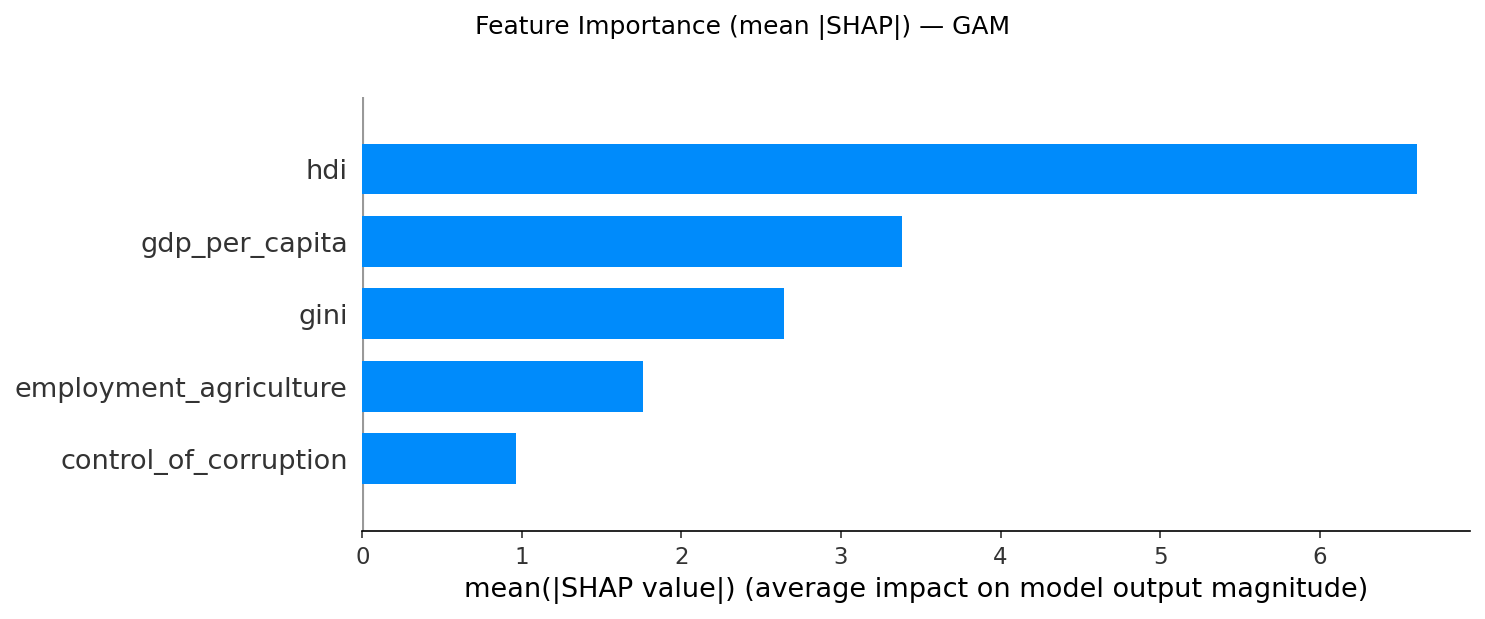

In [7]:
for model_name, (sv, X_plot) in all_shap.items():
    print(f"--- {model_name} ---")
    
    # Beeswarm summary plot
    shap.summary_plot(sv, X_plot, feature_names=FEATURES, show=False)
    fig = plt.gcf()
    fig.set_size_inches(10, 5)
    fig.suptitle(f"SHAP Summary — {model_name}", y=1.02)
    plt.tight_layout()
    plt.savefig(SHAP_DIR / f"summary_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # Bar plot (mean |SHAP|)
    shap.summary_plot(sv, X_plot, feature_names=FEATURES, plot_type="bar", show=False)
    fig = plt.gcf()
    fig.set_size_inches(10, 4)
    fig.suptitle(f"Feature Importance (mean |SHAP|) — {model_name}", y=1.02)
    plt.tight_layout()
    plt.savefig(SHAP_DIR / f"importance_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print()

## 2. Deep-dive: Best model

### Waterfall plots for 3 example countries

We pick one high-poverty, one mid-poverty, and one low-poverty country from the test set.

In [8]:
# Get SHAP values for the best model
sv_best, X_plot_best = all_shap[BEST_MODEL_NAME]


# Sort by actual poverty
sorted_idx = test_df[TARGET].sort_values()
n = len(sorted_idx)

low_idx = sorted_idx.index[n // 10]       # 10th percentile
mid_idx = sorted_idx.index[n // 2]         # median
high_idx = sorted_idx.index[9 * n // 10]   # 90th percentile

example_indices = {"Low poverty": low_idx, "Mid poverty": mid_idx, "High poverty": high_idx}

for label, idx in example_indices.items():
    row = test_df.loc[idx]
    print(f"{label}: {row['country_name']} ({row['year']}) — "
          f"actual poverty = {row[TARGET]:.2f}%")

Low poverty: Belgium (2016) — actual poverty = 0.10%
Mid poverty: Brazil (2023) — actual poverty = 3.80%
High poverty: Peru (2001) — actual poverty = 27.40%


In [9]:
# Reuse already-computed SHAP values from Cell 10
sv_best, X_plot_best = all_shap[BEST_MODEL_NAME]

# Create explainer ONLY to get base_value — do NOT call it on X_test
if BEST_MODEL_NAME in TREE_MODELS:
    explainer_best = shap.TreeExplainer(models[BEST_MODEL_NAME])
    base_value = explainer_best.expected_value
elif BEST_MODEL_NAME == "Ridge":
    explainer_best = shap.LinearExplainer(models[BEST_MODEL_NAME], X_train_scaled)
    base_value = explainer_best.expected_value
elif BEST_MODEL_NAME == "MLP":
    explainer_best = shap.KernelExplainer(models[BEST_MODEL_NAME].predict, X_bg_scaled.values)
    base_value = explainer_best.expected_value
else:  # GAM
    explainer_best = shap.KernelExplainer(models[BEST_MODEL_NAME].predict, X_bg.values)
    base_value = explainer_best.expected_value

base_value_scalar = float(np.array(base_value).flat[0])

# Build Explanation object from already-computed sv — no recomputation
explanation_best = shap.Explanation(
    values=sv_best,
    base_values=base_value_scalar,
    data=X_plot_best.values,
    feature_names=FEATURES
)

print(f"Base value (expected prediction): {base_value_scalar:.2f}")

Base value (expected prediction): 10.50


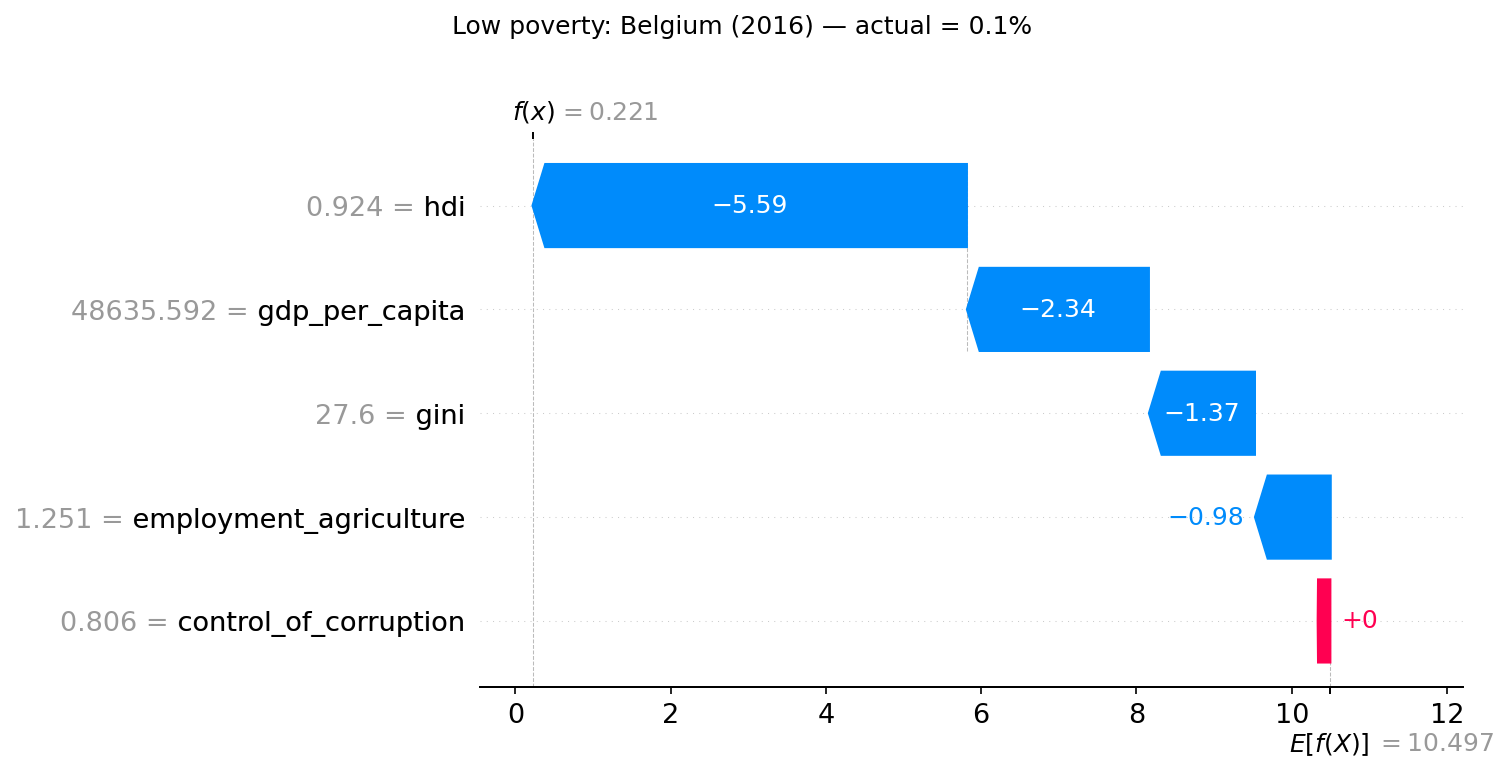

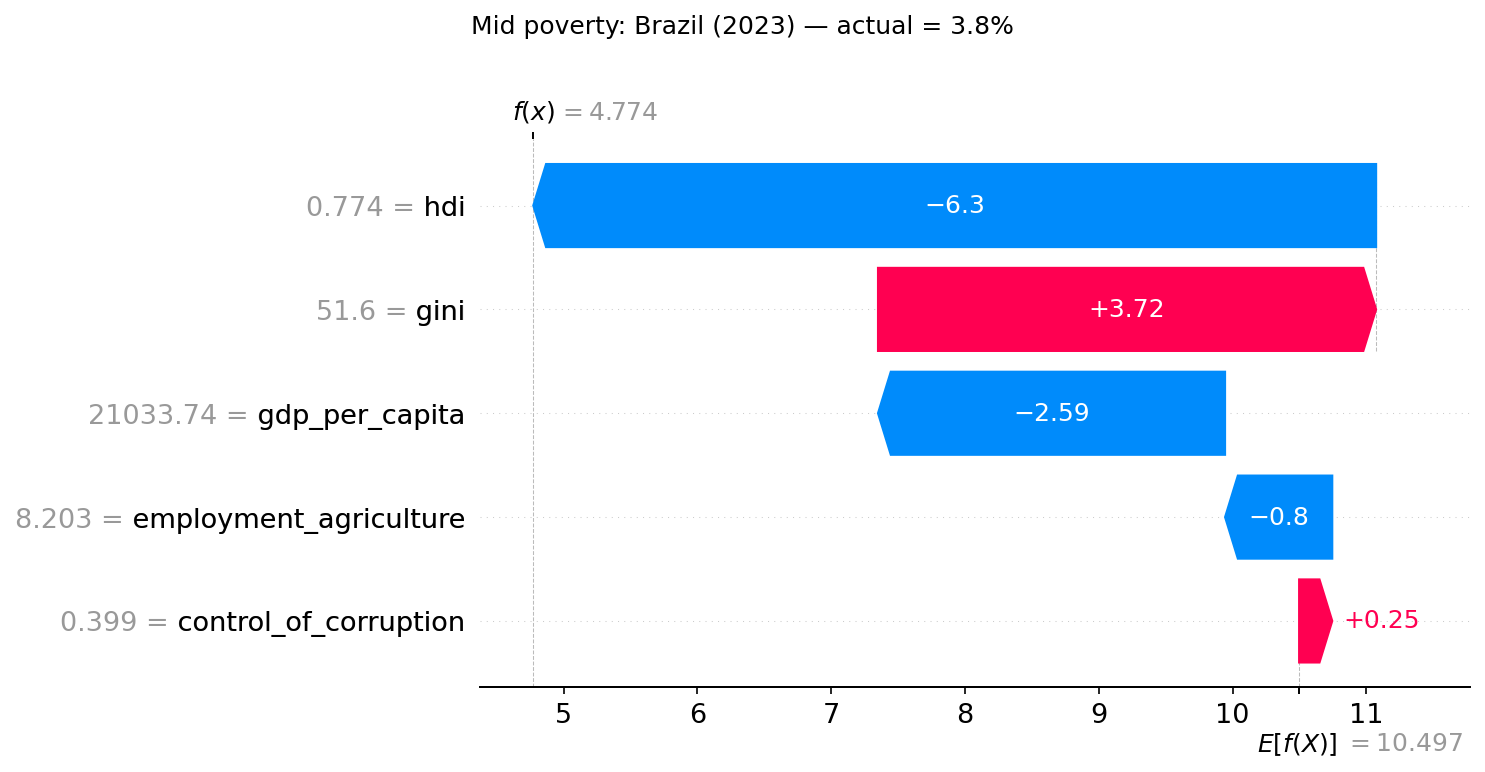

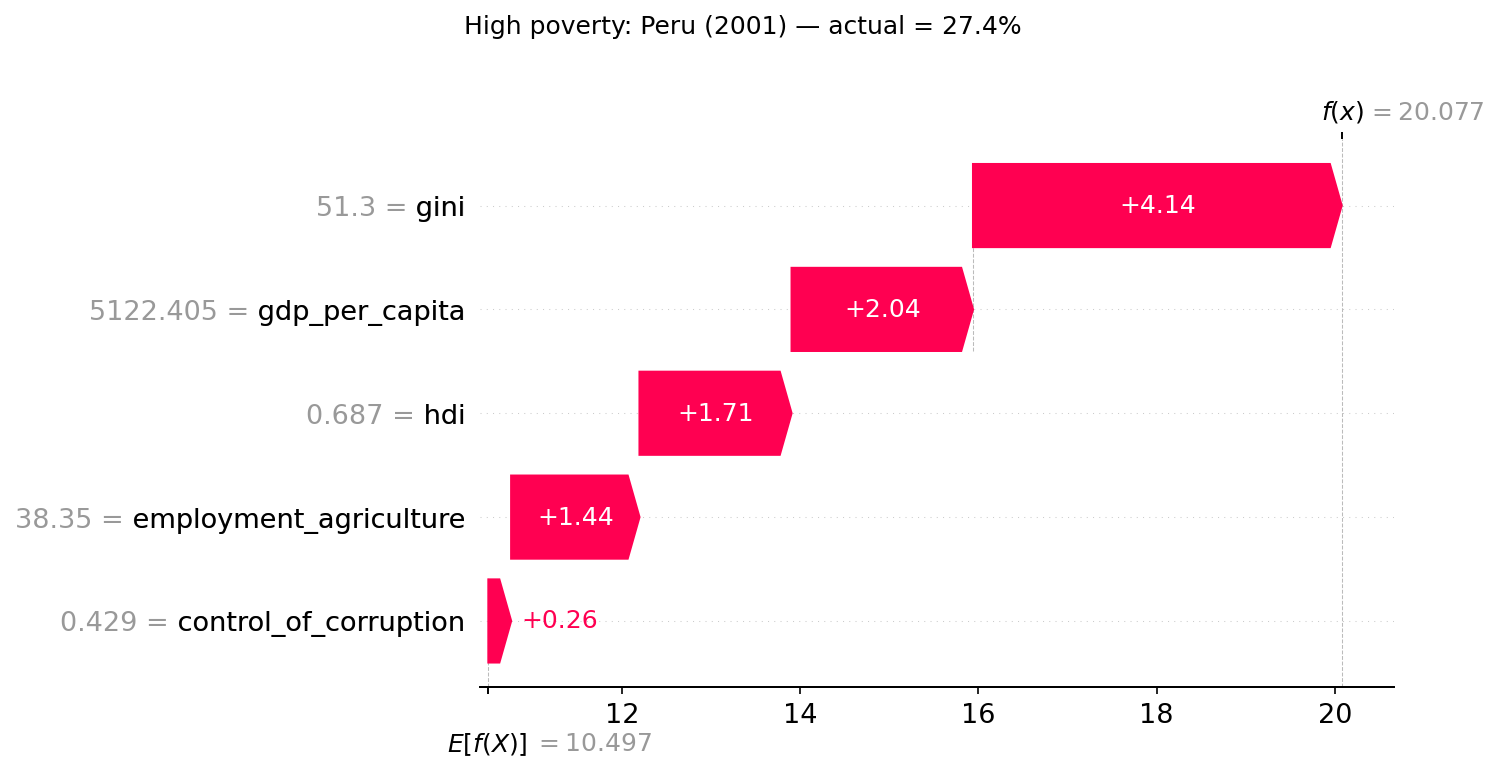

In [10]:
# Waterfall plots for the 3 example countries
# Map original DataFrame index to position in the test arrays
test_indices = test_df.index.tolist()

for label, orig_idx in example_indices.items():
    pos = test_indices.index(orig_idx)
    row = test_df.loc[orig_idx]
    
    shap.plots.waterfall(explanation_best[pos], show=False)
    fig = plt.gcf()
    fig.set_size_inches(10, 5)
    fig.suptitle(f"{label}: {row['country_name']} ({int(row['year'])}) — "
                 f"actual = {row[TARGET]:.1f}%", y=1.02)
    plt.tight_layout()
    safe_label = label.replace(" ", "_").lower()
    plt.savefig(SHAP_DIR / f"waterfall_{safe_label}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print()

### Dependence plots for the top 2 most important features

In [11]:
# Find top 2 features by mean |SHAP|
mean_abs_shap = np.abs(sv_best).mean(axis=0)
top2_idx = np.argsort(mean_abs_shap)[::-1][:2]
top2_features = [FEATURES[i] for i in top2_idx]
print(f"Top 2 features: {top2_features}")

Top 2 features: ['hdi', 'gdp_per_capita']


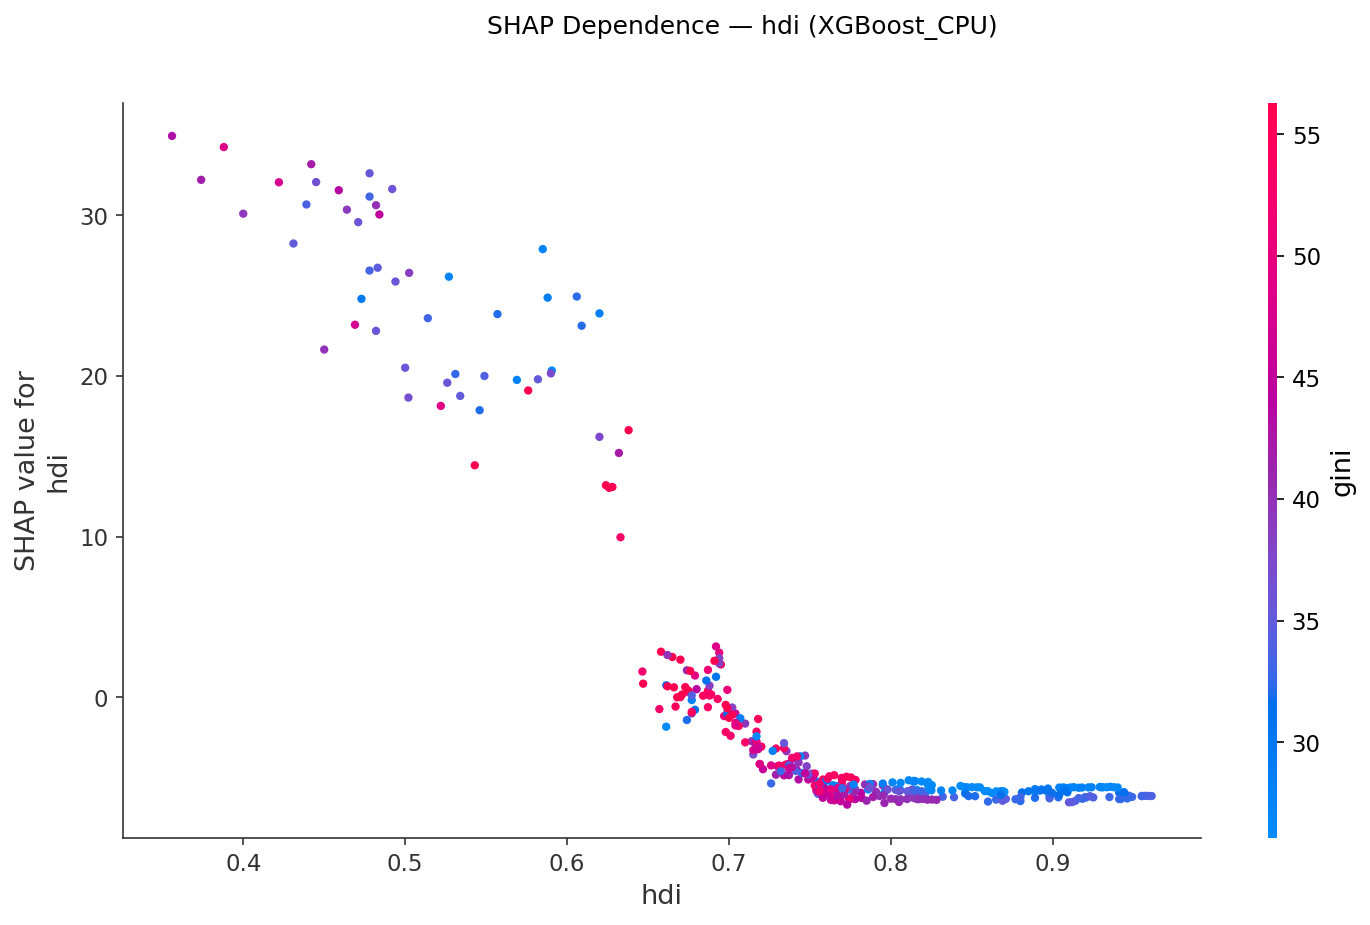

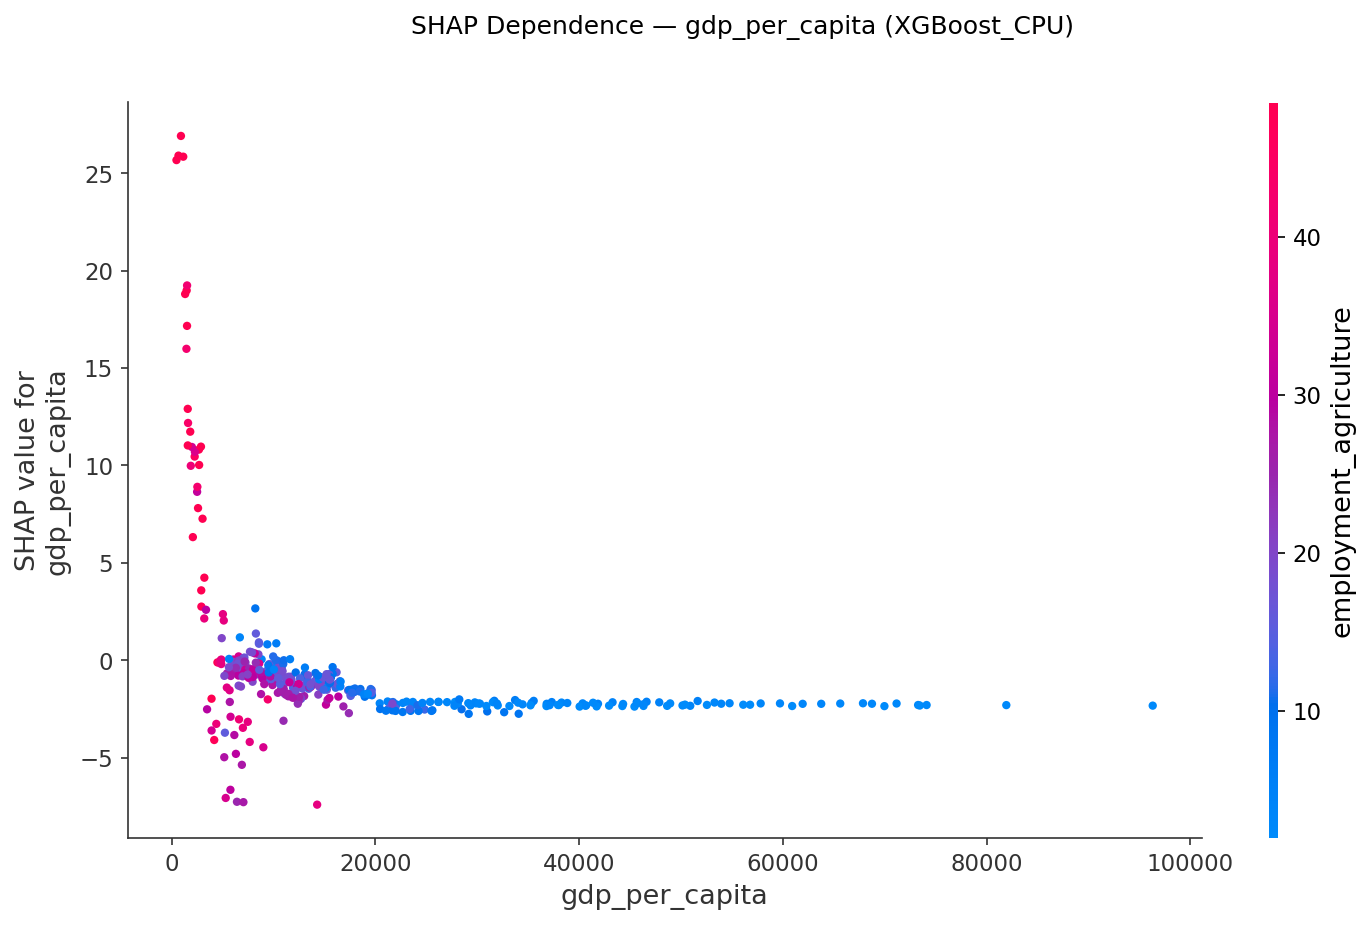

In [12]:
for feat_idx in top2_idx:
    shap.dependence_plot(
        feat_idx, sv_best, X_plot_best.values,
        feature_names=FEATURES, show=False
    )
    fig = plt.gcf()
    fig.set_size_inches(10, 6)
    fig.suptitle(f"SHAP Dependence — {FEATURES[feat_idx]} ({BEST_MODEL_NAME})", y=1.02)
    plt.tight_layout()
    plt.savefig(SHAP_DIR / f"dependence_{FEATURES[feat_idx]}.png", dpi=150, bbox_inches="tight")
    plt.show()

> **Note on HDI–GDP correlation:** HDI includes an income component (GNI per capita), creating partial overlap with `gdp_per_capita`. SHAP distributes importance across correlated features, so individual attributions should be interpreted with this multicollinearity in mind.

## 3. Scenario comparison: SSP1 vs SSP4 vs SSP5

For one country (Nigeria) in year 2050, compare SHAP explanations across scenarios.  
This shows **why** the model predicts different poverty levels under each pathway.

In [13]:
forecast = pd.read_csv(DATA_PROCESSED / "ssp_forecast_panel.csv")

# Pick country and year
COMPARE_COUNTRY = "Nigeria"
COMPARE_YEAR = 2050

# Get feature vectors for each scenario
scenario_rows = {}
for ssp in ["SSP1", "SSP4", "SSP5"]:
    row = forecast[
        (forecast["country_name"] == COMPARE_COUNTRY) &
        (forecast["year"] == COMPARE_YEAR) &
        (forecast["scenario"] == ssp)
    ]
    if len(row) == 0:
        print(f"WARNING: No data for {COMPARE_COUNTRY} / {ssp} / {COMPARE_YEAR}")
        # Try alternative country
        available = forecast[
            (forecast["year"] == COMPARE_YEAR) & (forecast["scenario"] == ssp)
        ]["country_name"].unique()
        print(f"  Available countries: {available[:10]}")
        continue
    scenario_rows[ssp] = row[FEATURES].iloc[0]

if len(scenario_rows) == 3:
    print(f"\nFeature values for {COMPARE_COUNTRY} in {COMPARE_YEAR}:")
    comparison_df = pd.DataFrame(scenario_rows).T
    comparison_df.columns = FEATURES
    print(comparison_df.round(4))
else:
    missing = [s for s in ["SSP1", "SSP4", "SSP5"] if s not in scenario_rows]
    raise ValueError(f"Missing data for {COMPARE_COUNTRY} / {COMPARE_YEAR}: {missing}")



Feature values for Nigeria in 2050:
      gdp_per_capita     hdi  control_of_corruption  employment_agriculture  \
SSP1         10851.2  0.7026                 0.4790                   17.29   
SSP4          7547.8  0.4816                 0.3145                   34.28   
SSP5         12598.7  0.7115                 0.4611                   13.55   

        gini  
SSP1  43.374  
SSP4  50.857  
SSP5  42.227  


In [14]:
# Compute SHAP values for each scenario's feature vector
scenario_explanations = {}
scenario_predictions = {}                    # ← neu

for ssp, features_row in scenario_rows.items():
    X_single = features_row.values.reshape(1, -1)
    
    # Scale if needed
    if BEST_MODEL_NAME in NEEDS_SCALING:
        X_single_input = scaler.transform(X_single)
    else:
        X_single_input = X_single
    
    # Get SHAP explanation
    if BEST_MODEL_NAME in TREE_MODELS:
        expl = explainer_best(pd.DataFrame(X_single, columns=FEATURES))
    elif BEST_MODEL_NAME == "Ridge":
        expl = explainer_best(pd.DataFrame(X_single_input, columns=FEATURES))
        expl.data = X_single  # show unscaled
    else:
        expl = explainer_best(X_single_input)
        expl.data = X_single
    
    expl.feature_names = FEATURES
    scenario_explanations[ssp] = expl
    
    pred = float(np.array(models[BEST_MODEL_NAME].predict(X_single_input)).flat[0])
    scenario_predictions[ssp] = pred         # ← neu
    print(f"{ssp}: predicted poverty = {pred:.2f}%")

SSP1: predicted poverty = 9.01%
SSP4: predicted poverty = 40.09%
SSP5: predicted poverty = 4.97%


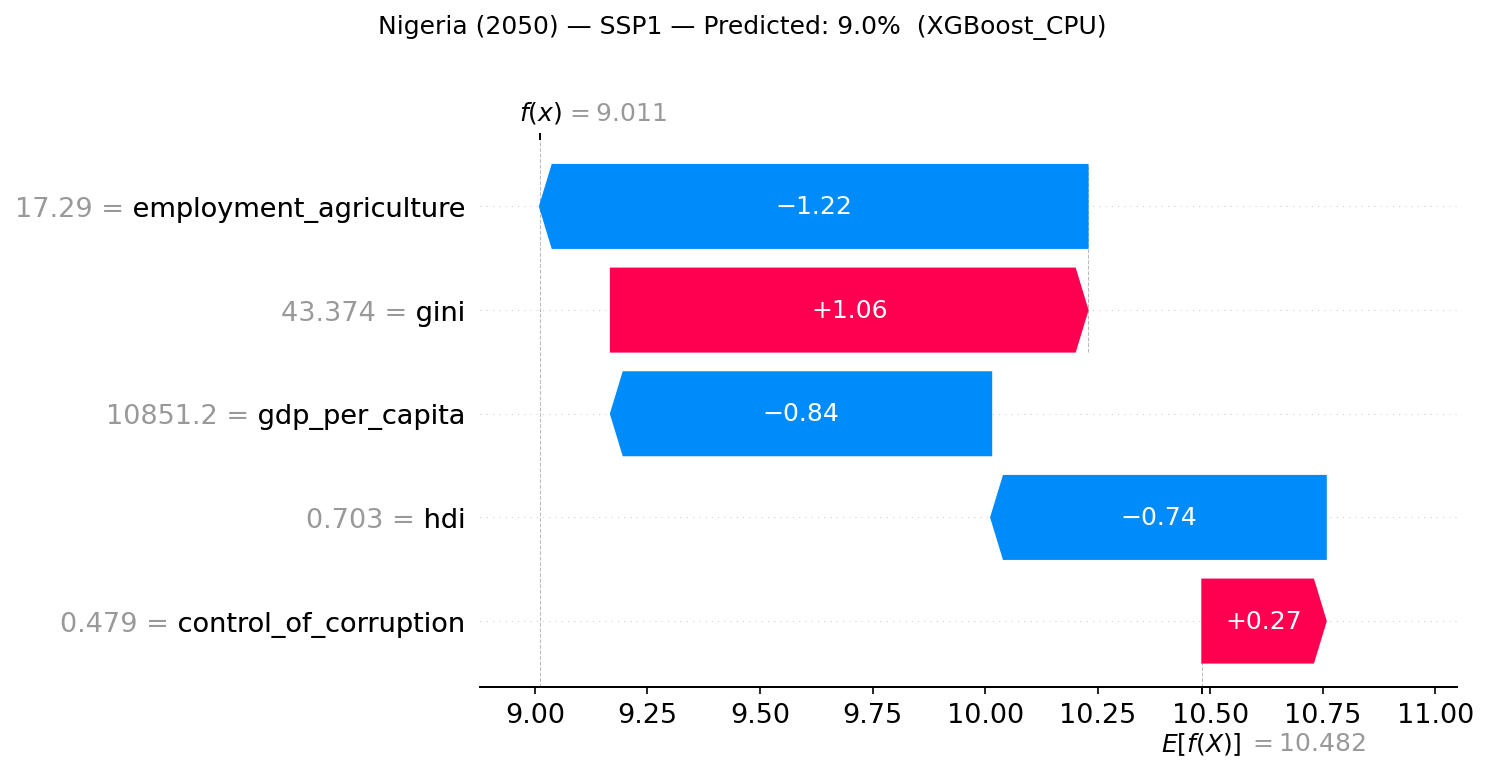

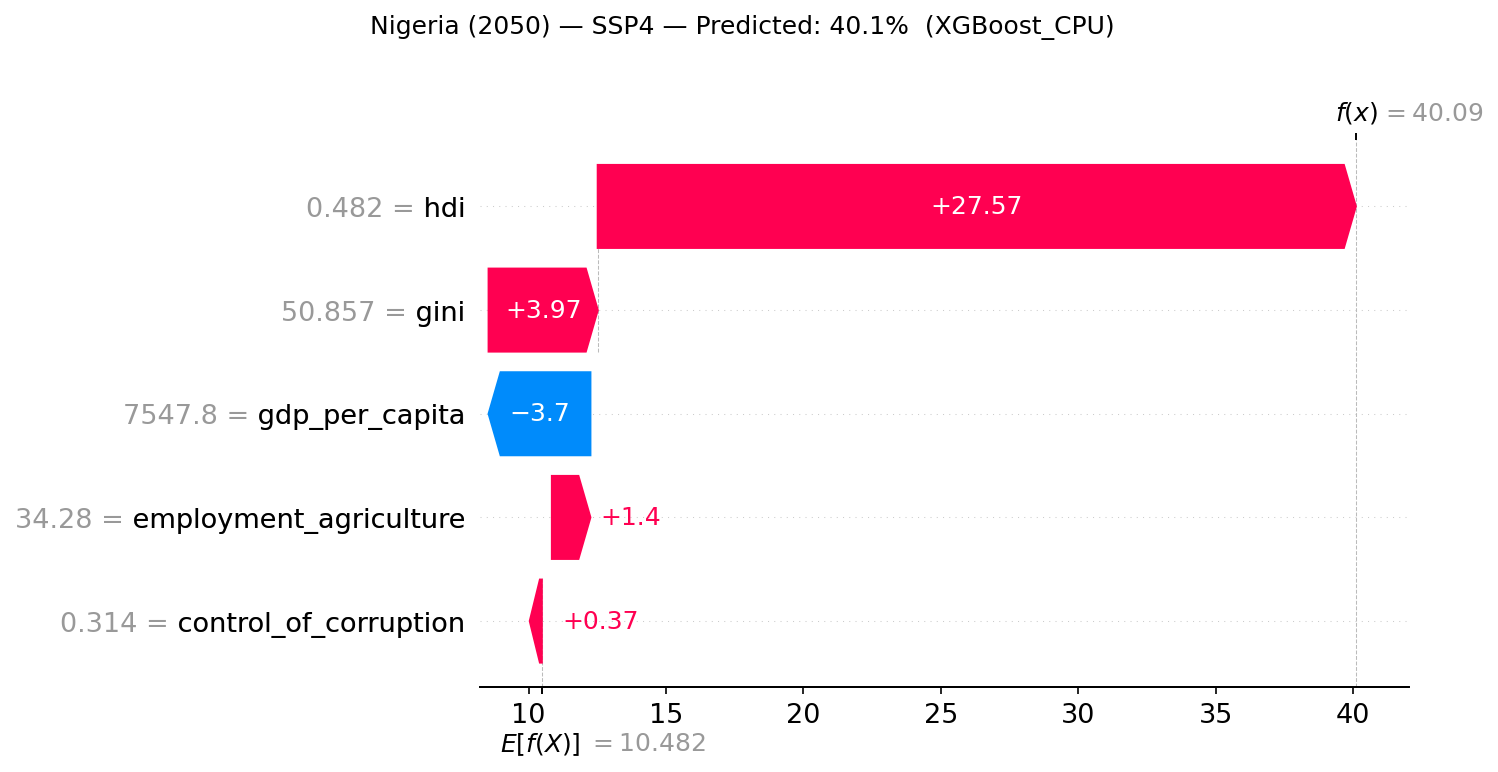

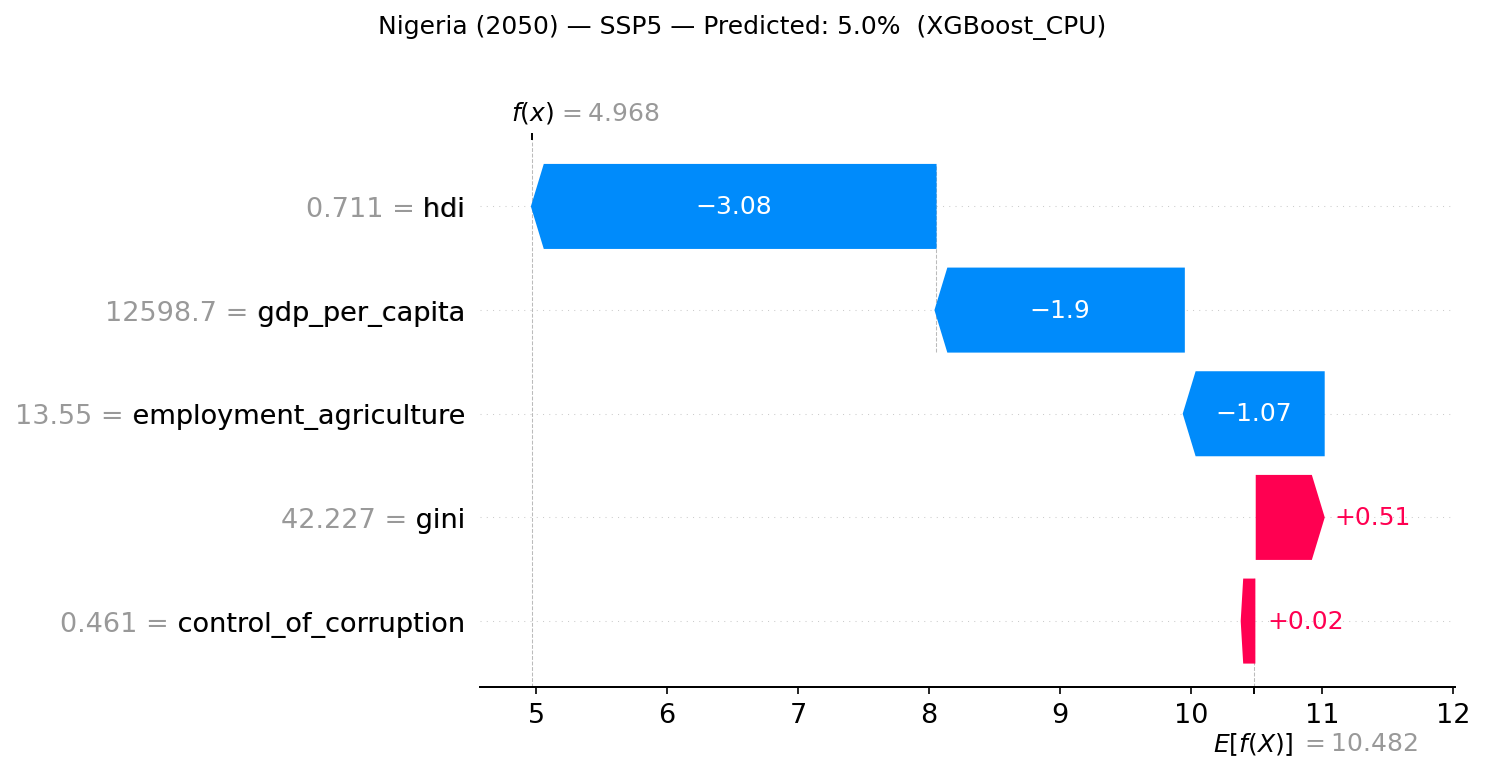

Saved: outputs/shap/scenario_SSP*.png


In [15]:
# Individual waterfall plots for each scenario (side-by-side rendering is unreliable with SHAP)
for ssp, expl in scenario_explanations.items():
    pred = scenario_predictions[ssp]
    shap.plots.waterfall(expl[0], show=False)
    fig = plt.gcf()
    fig.set_size_inches(10, 5)
    fig.suptitle(f"{COMPARE_COUNTRY} ({COMPARE_YEAR}) — {ssp} — Predicted: {pred:.1f}%  ({BEST_MODEL_NAME})",
                 y=1.02)
    plt.tight_layout()
    plt.savefig(SHAP_DIR / f"scenario_{ssp}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Saved: outputs/shap/scenario_SSP*.png")

## 4. Cross-model feature importance comparison

Extract mean |SHAP| per feature from each model and compare in a grouped bar chart.

In [16]:
# Build importance table
importance_data = []

for model_name, (sv, _) in all_shap.items():
    mean_abs = np.abs(sv).mean(axis=0)
    for i, feat in enumerate(FEATURES):
        importance_data.append({
            "Model": model_name,
            "Feature": feat,
            "mean_abs_SHAP": mean_abs[i]
        })

imp_df = pd.DataFrame(importance_data)

# Pivot for display
imp_pivot = imp_df.pivot(index="Feature", columns="Model", values="mean_abs_SHAP")
print("Mean |SHAP| per feature per model:")
print(imp_pivot.round(4))

Mean |SHAP| per feature per model:
Model                      GAM  LightGBM     MLP  RandomForest    Ridge  \
Feature                                                                   
control_of_corruption   0.9639    1.0262  1.2956        0.3263   3.1174   
employment_agriculture  1.7569    0.8478  1.5255        0.7569   2.8710   
gdp_per_capita          3.3835    2.6064  2.4186        2.2050   2.4690   
gini                    2.6423    2.9970  3.1266        2.2956   1.4553   
hdi                     6.6126    7.9618  6.1508        8.3526  10.8998   

Model                   XGBoost_CPU  XGBoost_GPU  
Feature                                           
control_of_corruption        0.4051       0.4051  
employment_agriculture       0.8813       0.8813  
gdp_per_capita               2.5208       2.5208  
gini                         2.3650       2.3650  
hdi                          7.4473       7.4473  


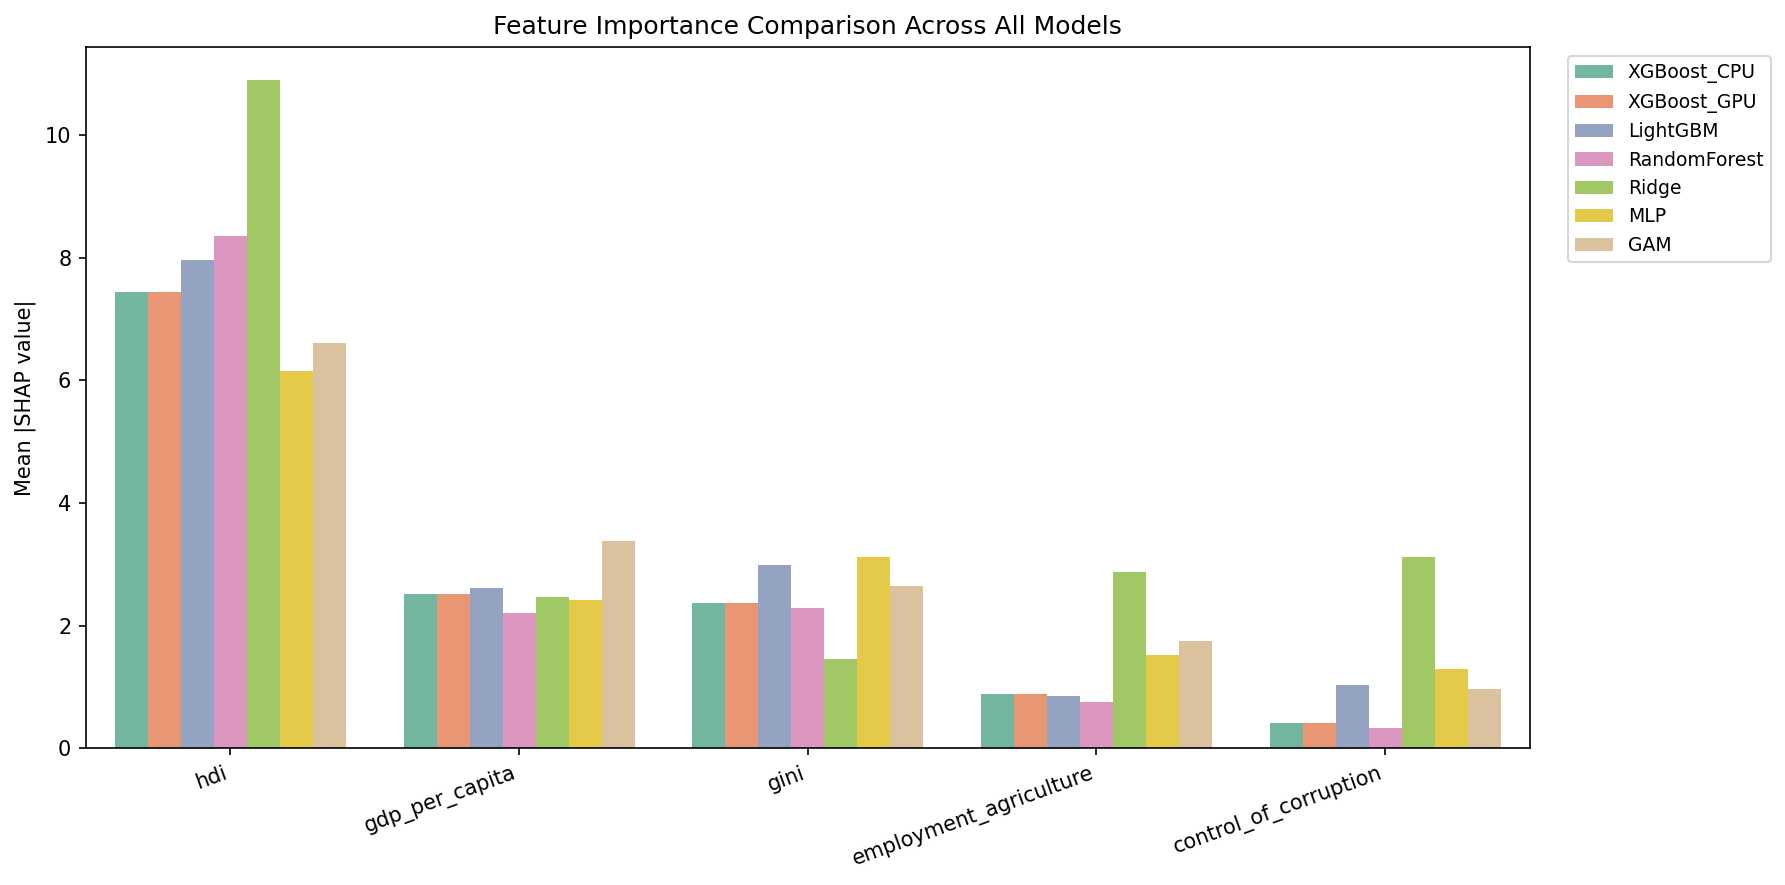

Saved: outputs/shap/feature_importance_all_models.png


In [17]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Order features by average importance across models
feat_order = imp_df.groupby("Feature")["mean_abs_SHAP"].mean().sort_values(ascending=False).index
imp_df["Feature"] = pd.Categorical(imp_df["Feature"], categories=feat_order, ordered=True)

sns.barplot(
    data=imp_df, x="Feature", y="mean_abs_SHAP", hue="Model",
    ax=ax, palette="Set2"
)
ax.set_ylabel("Mean |SHAP value|")
ax.set_xlabel("")
ax.set_title("Feature Importance Comparison Across All Models")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.savefig(SHAP_DIR / "feature_importance_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/shap/feature_importance_all_models.png")

## 5. GAM partial dependence plots

A unique advantage of GAMs: we can directly visualize the smooth function learned for each feature.  
This shows how each feature relates to poverty, holding other features constant.

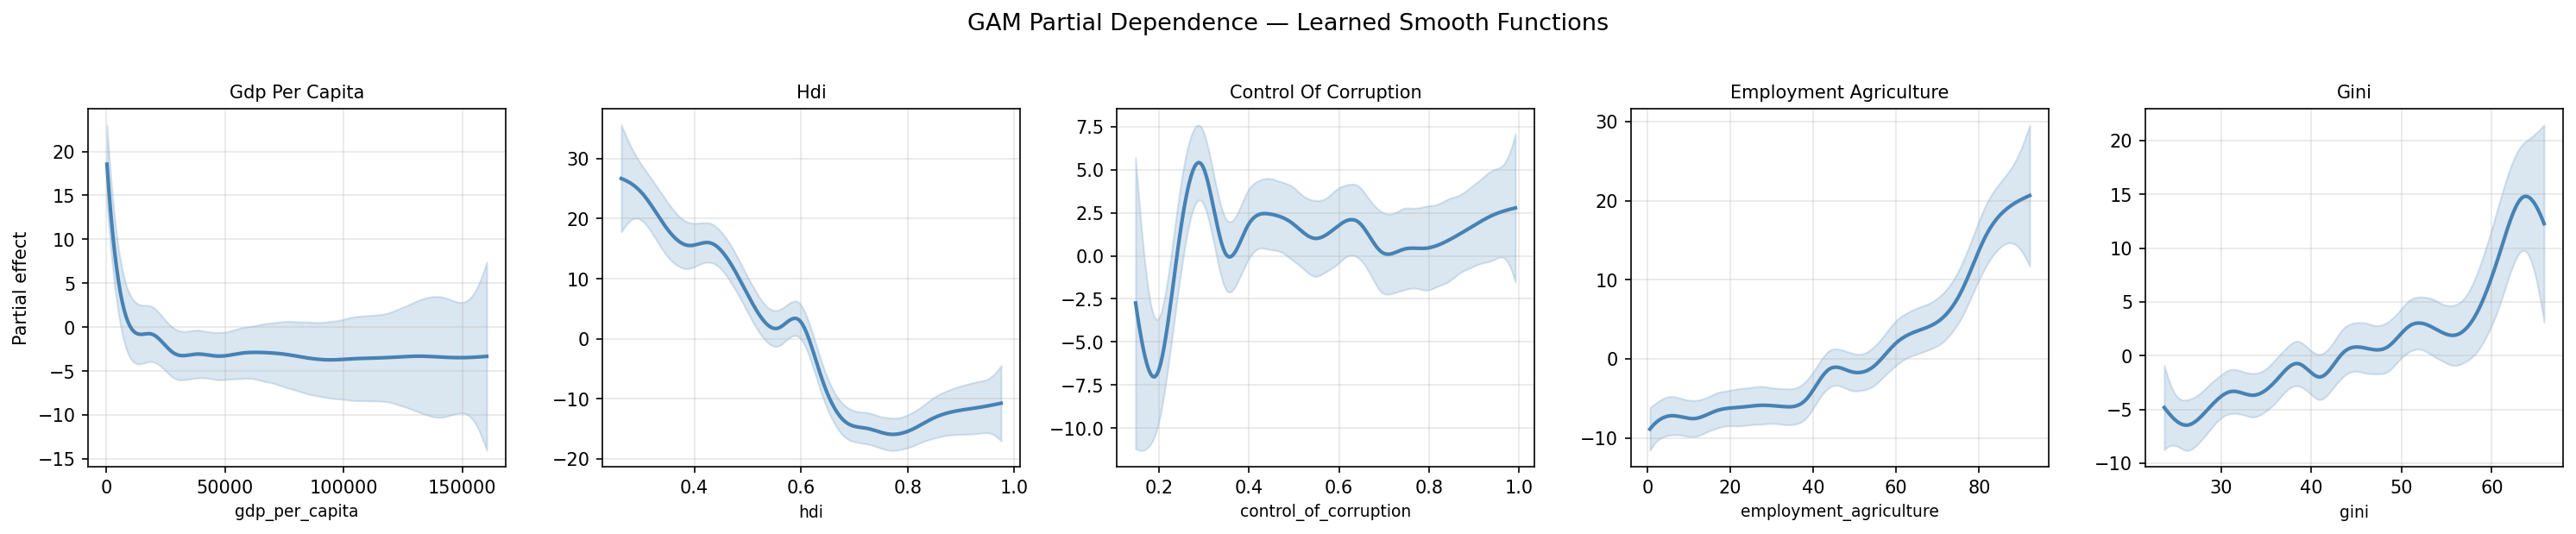

Saved: outputs/shap/gam_partial_dependence.png


In [18]:
gam_model = models.get("GAM")

if gam_model is None:
    print("GAM model not loaded — skipping partial dependence plots.")
else:
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    for i, (ax, feat) in enumerate(zip(axes, FEATURES)):
        # Generate grid for this feature
        XX = gam_model.generate_X_grid(term=i, n=200)
        
        # Get partial dependence
        pdep, confi = gam_model.partial_dependence(term=i, X=XX, width=0.95)
        
        ax.plot(XX[:, i], pdep, color="steelblue", linewidth=2)
        ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.2, color="steelblue")
        
        ax.set_xlabel(feat, fontsize=9)
        ax.set_ylabel("Partial effect" if i == 0 else "")
        ax.set_title(feat.replace("_", " ").title(), fontsize=10)
        ax.grid(alpha=0.3)
    
    fig.suptitle("GAM Partial Dependence — Learned Smooth Functions", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(SHAP_DIR / "gam_partial_dependence.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: outputs/shap/gam_partial_dependence.png")

---
**Outputs produced (all in `outputs/shap/`):**
- `summary_{model}.png` × 7 — beeswarm SHAP plots
- `importance_{model}.png` × 7 — bar plots of mean |SHAP|
- `waterfall_low_poverty.png`, `waterfall_mid_poverty.png`, `waterfall_high_poverty.png` — example explanations
- `dependence_{feature}.png` × 2 — dependence plots for top features
- `scenario_SSP1.png`, `scenario_SSP4.png`, `scenario_SSP5.png` — SSP waterfall plots for Nigeria 2050
- `feature_importance_all_models.png` — cross-model grouped bar chart
- `gam_partial_dependence.png` — GAM smooth functions for all 5 features